In [1]:
import pandas as pd
import numpy as np      
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
data = pd.read_csv("/Users/vaibhavnegi/Desktop/airline_prediction/airlines_flights_data.csv")

In [3]:
data.drop(columns = 'index', inplace = True)

In [4]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


1: Price Distribution (Statistical Understanding)

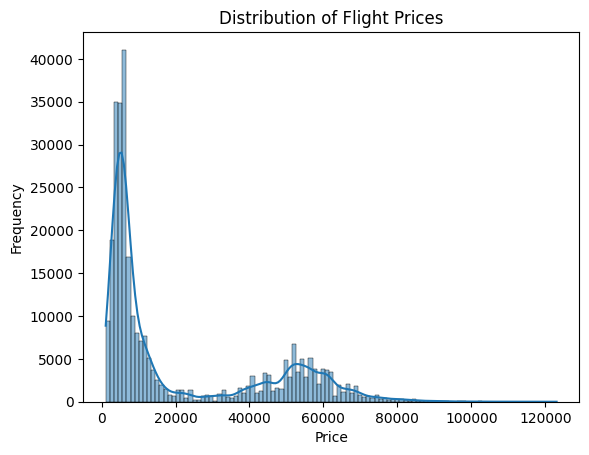

In [10]:


sns.histplot(data['price'], kde=True)
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Interpretation

Shows how prices are distributed.

Helps check normality assumption before statistical testing

-------------------------------x------------------------------------------

2: Do Flight Prices Differ by Airline? (ANOVA)
Hypothesis

H0: All airlines have the same average price


H1: At least one airline has a different average price

In [5]:


airlines = data['airline'].unique()

groups = [data[data['airline'] == airline]['price'] for airline in airlines]

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 17194.40209609313
P-value: 0.0


Interpretation

p < 0.05 → Reject H0

Airlines significantly affect flight prices.

3: T-Test (Stops vs Price)
Hypothesis


H0: Price of non-stop flights = multi-stop flights

H1: Prices are different

In [8]:
# STATISTICAL TESTING



# Create groups
non_stop = data[data['stops'] == 'zero']['price']
multi_stop = data[data['stops'].isin(['one','two_or_more'])]['price']

# Perform T-test
t_stat, p_value = stats.ttest_ind(non_stop, multi_stop)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -104.4496043090858
P-value: 0.0


Reject the Null Hypothesis (H0)

This means:

The number of stops has a statistically significant impact on flight price.


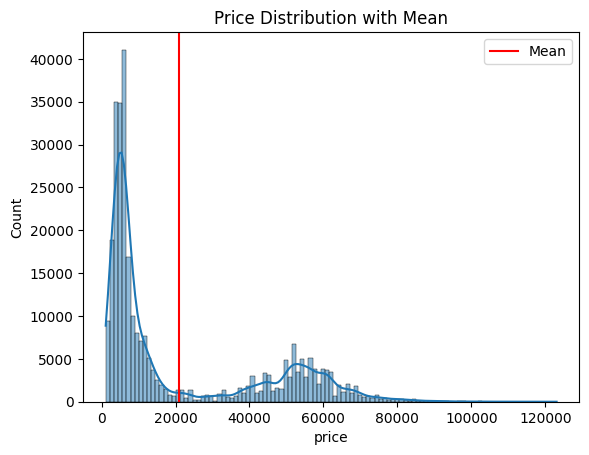

In [9]:
# graphical representation 
sns.histplot(data['price'], kde=True)

plt.axvline(data['price'].mean(), color='red', label='Mean')
plt.title("Price Distribution with Mean")
plt.legend()
plt.show()

4: Confidence Interval for Average Price

In [11]:
# STATISTICAL CALCULATIONS


mean_price = np.mean(data['price'])
std_price = np.std(data['price'], ddof=1)
n = len(data)

ci = stats.t.interval(
        0.95,
        df=n-1,
        loc=mean_price,
        scale=std_price/np.sqrt(n)
)

print("Mean Price:", mean_price)
print("95% Confidence Interval:", ci)

Mean Price: 20889.660523133203
95% Confidence Interval: (np.float64(20808.459474340427), np.float64(20970.86157192598))


This means:

 The average flight price in your dataset is about ₹20,889.

-----------------------------------X---------------------------------------------------------

5️: Correlation Analysis (Duration vs Price)

In [12]:
# statistical test 

corr, p_value = stats.pearsonr(data['duration'], data['price'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.2042223678454266
P-value: 0.0


➡ As flight duration increases, the price tends to increase slightly, but the relationship is not very strong.
So:
 Longer flights may cost more, but duration alone does not strongly determine price.

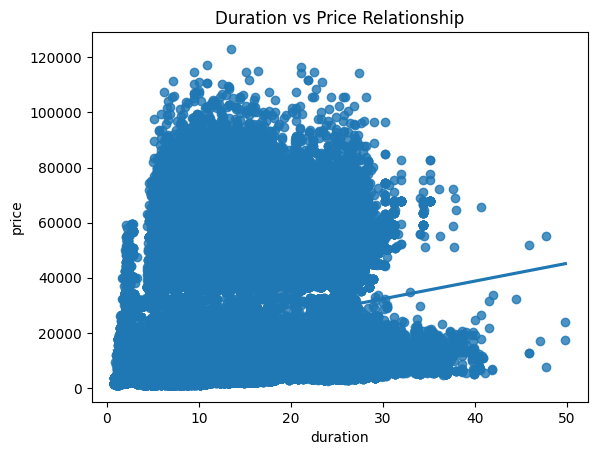

In [13]:
# graphical representation

sns.regplot(x='duration', y='price', data=data)

plt.title("Duration vs Price Relationship")
plt.show()